In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt


In [3]:
df = pd.read_csv("Instagram_visits_clustering.csv")

In [4]:
df

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397
...,...,...,...
2595,2595,25,25.745908
2596,2596,52,9.275066
2597,2597,100,84.999487
2598,2598,87,20.530806


In [5]:

X = df[["Instagram visit score", "Spending_rank(0 to 100)"]]
X_scaled = StandardScaler().fit_transform(X)   

# for k in range(1, 6):
#     print(f"the no. of cluster is: {k}")
#     labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
#     print(k, round(silhouette_score(X_scaled, labels), 3))

In [8]:
X_scaled

array([[-0.01217181, -0.65376894],
       [-0.08743151, -0.61298749],
       [ 1.53065202, -0.84583579],
       ...,
       [ 1.38013262,  1.46598081],
       [ 0.89094458, -0.77618835],
       [-1.10343744,  1.16650181]], shape=(2600, 2))

In [9]:

for k in range(2, 6):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    print(k, round(silhouette_score(X_scaled, labels), 3), km.inertia_)
labels

2 0.469 2894.453828798832
3 0.602 1098.5276494221519
4 0.646 593.5744810683258
5 0.628 364.8689617008572


array([0, 0, 4, ..., 2, 4, 1], shape=(2600,), dtype=int32)

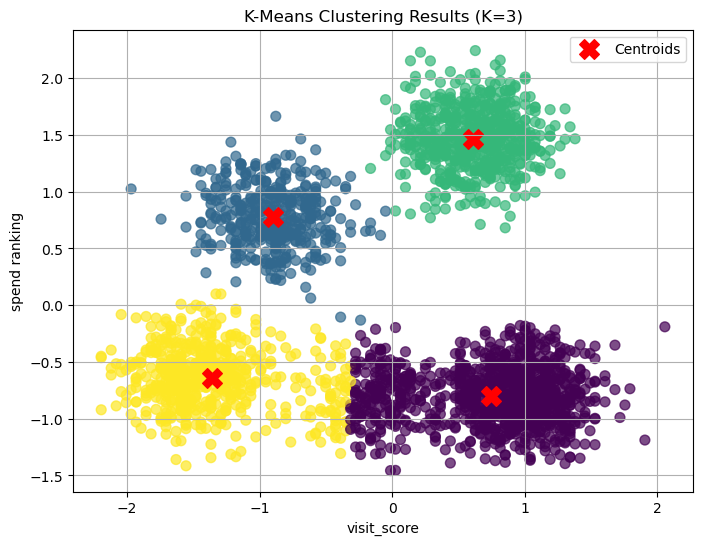

In [18]:
# The [:, 0] syntax means "give me all the rows, but only column 0"
x_axis_data = X_scaled[:, 0] 
y_axis_data = X_scaled[:, 1]

# 2. Set up the canvas size
plt.figure(figsize=(8, 6))

# 3. Plot the data points
# THE MAGIC TRICK: c=labels tells matplotlib to color each dot based on its group number
plt.scatter(x_axis_data, y_axis_data, c=labels, cmap='viridis', s=50, alpha=0.7)

# 4. Plot the Centroids (the center pins)
# km.cluster_centers_ contains the exact coordinates of your final centroids
centroids_x = km.cluster_centers_[:, 0]
centroids_y = km.cluster_centers_[:, 1]

# We use a giant red 'X' so the centroids stand out from the data points
plt.scatter(centroids_x, centroids_y, c='red', s=200, marker='X', label='Centroids')

# 5. Make it look nice and display it
plt.title('K-Means Clustering Results (K=3)')
plt.xlabel('visit_score')
plt.ylabel('spend ranking')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)
labels

array([0, 0, 0, ..., 2, 0, 1], shape=(2600,), dtype=int32)

In [19]:
df['label'] = labels

In [20]:
df[df['label'] ==0].mean()

User ID                    1283.451801
Instagram visit score        83.243427
Spending_rank(0 to 100)      19.872486
label                         0.000000
dtype: float64

In [21]:
df[df['label'] ==1].mean()

User ID                    1284.745000
Instagram visit score        39.350000
Spending_rank(0 to 100)      65.132485
label                         1.000000
dtype: float64

In [22]:
df[df['label'] ==2].mean()

User ID                    1330.385000
Instagram visit score        79.615000
Spending_rank(0 to 100)      85.024498
label                         2.000000
dtype: float64

In [23]:
df[df['label'] ==3].mean()

User ID                    1306.223386
Instagram visit score        27.296684
Spending_rank(0 to 100)      24.309119
label                         3.000000
dtype: float64